In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('../data/processed/train_cleaned.csv', parse_dates=['date'])

train.head()

,date,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster,transactions,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13,0.0,1
1,2013-01-01,1,BABY CARE,0.0,0,93.14,Quito,Pichincha,D,13,0.0,1
2,2013-01-01,1,BEAUTY,0.0,0,93.14,Quito,Pichincha,D,13,0.0,1
3,2013-01-01,1,BEVERAGES,0.0,0,93.14,Quito,Pichincha,D,13,0.0,1
4,2013-01-01,1,BOOKS,0.0,0,93.14,Quito,Pichincha,D,13,0.0,1


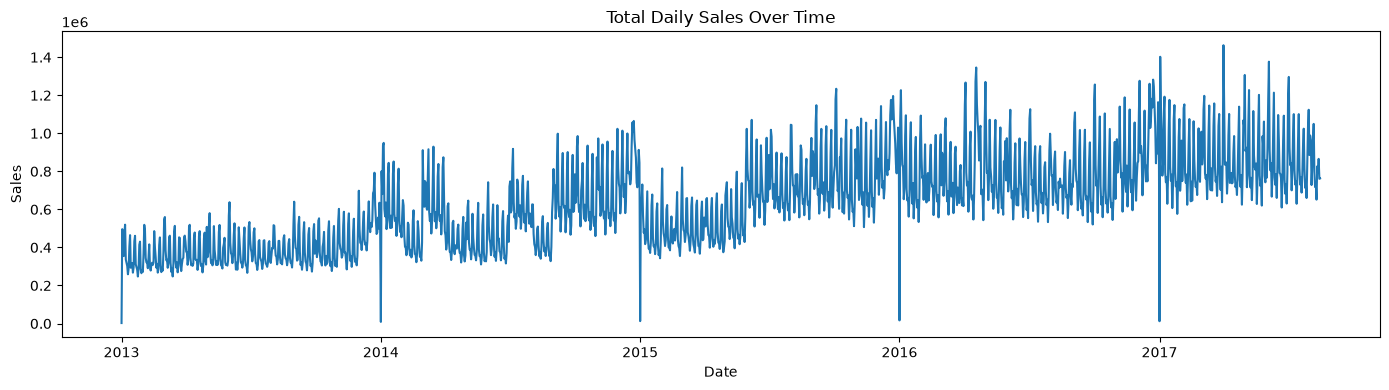

In [4]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

In [5]:
low_sales = daily_sales[daily_sales['sales'] < 100000].sort_values('sales')
print(low_sales)

           date         sales
0    2013-01-01   2511.618999
364  2014-01-01   8602.065404
1457 2017-01-01  12082.500997
728  2015-01-01  12773.616980
1092 2016-01-01  16433.394000


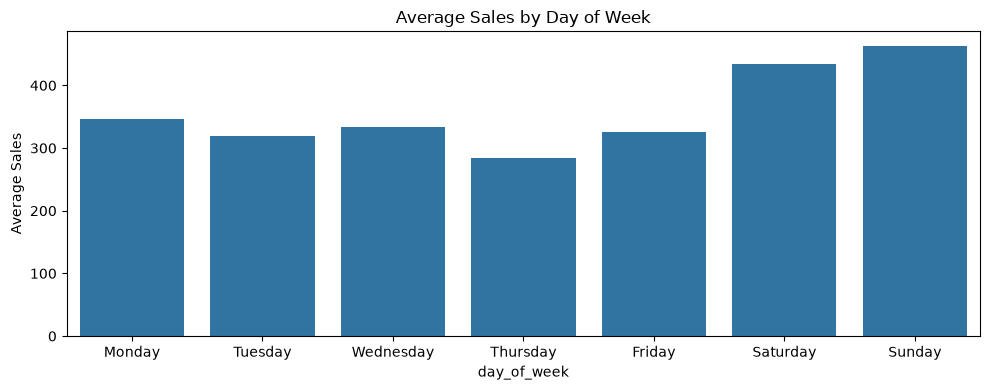

In [8]:
train['day_of_week'] = train['date'].dt.day_name()

weekly = train.groupby('day_of_week')['sales'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 4))
sns.barplot(x=weekly.index, y=weekly.values)
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

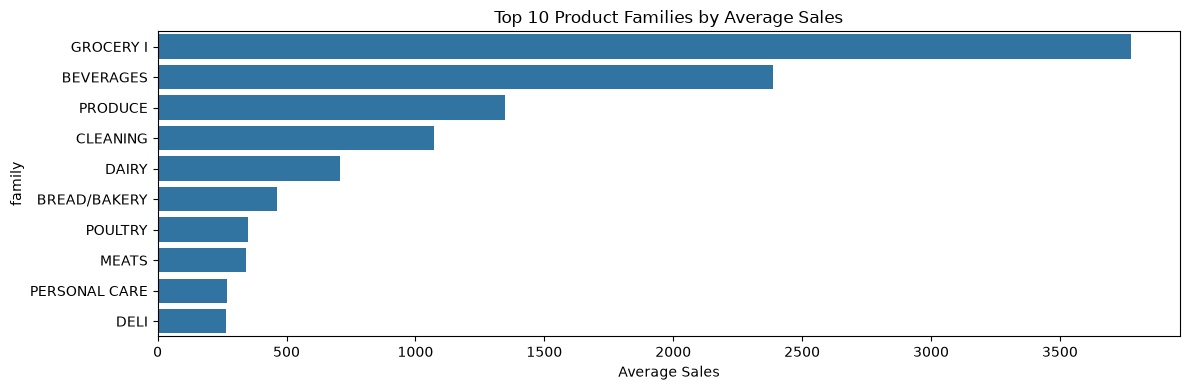

In [9]:
family_sales = train.groupby('family')['sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 4))
sns.barplot(x=family_sales.values, y=family_sales.index)
plt.title('Top 10 Product Families by Average Sales')
plt.xlabel('Average Sales')
plt.tight_layout()
plt.show()

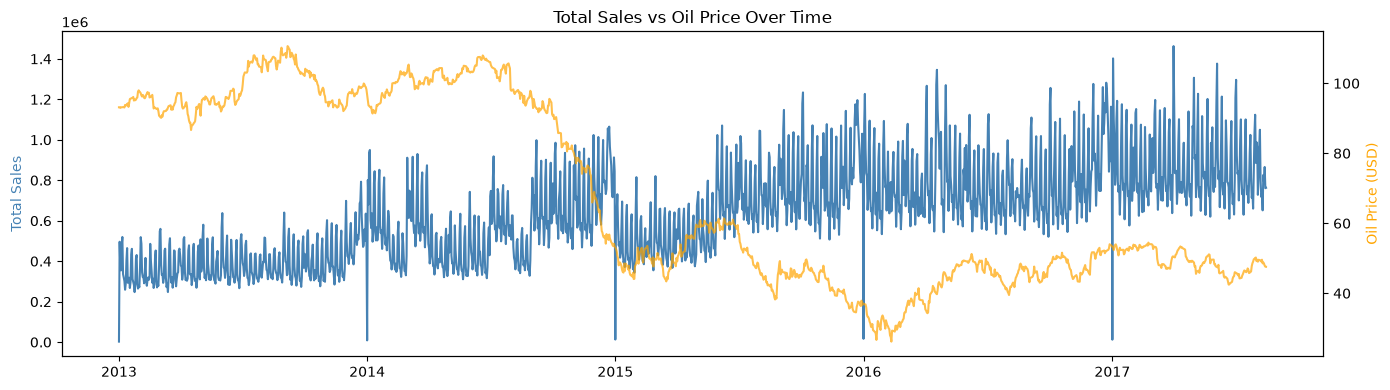

In [10]:
oil_sales = train.groupby('date').agg({'sales': 'sum', 'dcoilwtico': 'mean'}).reset_index()

plt.figure(figsize=(14, 4))

ax1 = plt.gca()
ax1.plot(oil_sales['date'], oil_sales['sales'], color='steelblue', label='Sales')
ax1.set_ylabel('Total Sales', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(oil_sales['date'], oil_sales['dcoilwtico'], color='orange', alpha=0.7, label='Oil Price')
ax2.set_ylabel('Oil Price (USD)', color='orange')

plt.title('Total Sales vs Oil Price Over Time')
plt.tight_layout()
plt.show()

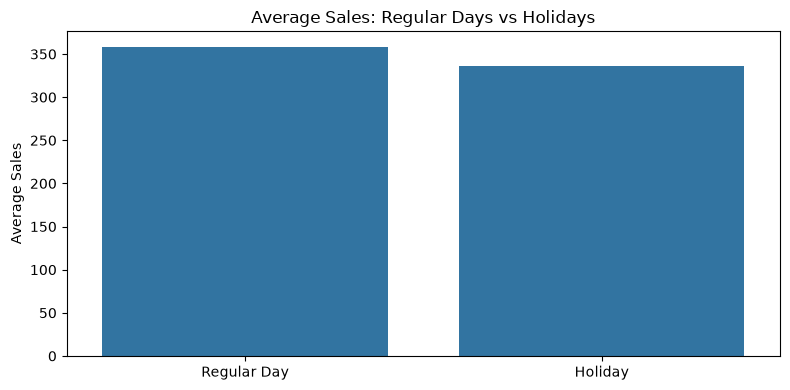

In [11]:
holiday_sales = train.groupby('is_holiday')['sales'].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=['Regular Day', 'Holiday'], y=holiday_sales.values)
plt.title('Average Sales: Regular Days vs Holidays')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

## Key Insights

- Sales show a clear **upward trend** from 2013 to 2017
- **January 1st (New Year)** consistently shows near-zero sales across all years
- **Weekends** (Saturday and Sunday) have significantly higher sales than weekdays
- **GROCERY I** and **BEVERAGES** are by far the top product categories
- Oil price shows an **inverse relationship** with sales as oil prices dropped in 2015, sales increased, possibly due to a shift from restaurants to home cooking
- **National holidays** show slightly lower sales than regular days peak buying happens in the days before holidays